<font size=6>**Advanced RAG**</font>

<font size=5>**Multi-Modal RAG for Healthcare**</font>

# 🧾 Assignment Worksheet: Advanced Retrieval-Augmented Generation (RAG)  
**Course:** Applied Generative AI  
**Assignment:** M12 – Exploring and Evaluating Advanced RAG Techniques  
**Instructions:** Use this worksheet to answer all conceptual and evaluation questions. The rest of the notebook is for code, experimentation, and outputs. Your responses should reflect your understanding of RAG architecture, performance evaluation, and generative response behavior.

---

## ✅ Part 1: Understanding the Pipeline (10 pts)

**Q1.1 (3 pts)** What vector database or retrieval backend is used in this notebook? How does it differ from traditional keyword search?
 - This RAG system uses the standard vector database seperated into two seperate sections, one for document embedding and another for images. In addition to the image embedding, the images also contain Metadata, containing additional information about the image. Additionally, after retreiving the relevant documents/images, the system also runs a reranker in order to list the most relevant documents/images first. Compared to a traditional keyword search, the vector embedding allows for the system to connect documents that may not contain the actual keyword being searched, but includes information regarding that topic.

**Q1.2 (4 pts)** What are the main components in the RAG pipeline used here?  
*List and briefly explain each component (e.g., retriever, reranker, generator).*
 - In this Rag pipleine, there are three main components each with several subcomponents. The main components include Data Ingestion, the Retrieval System, and then the Response Generation. 
 - The Data ingestion part of the system takes the PDF documents and images with their metadata and embedding it into a Vector Database to be used later. 
 - In the Retreival System, the system takes a user query, expands it with additional information, before performing vector search on the database created in the previous section. Once results are returned, the retrieved data then gets reranked in order of most relevant documents. Finally, the reranked documents are added as context for the LLM to use in the next component. 
 - Finally there is the Response Generation section that takes the user query enhanced with its expanded information and retrieved context and sends it into a LLM model to retrun a response.

**Q1.3 (3 pts)** How are documents chunked and embedded for retrieval? Why does chunking strategy matter?
 - In the original case, the document is embedded in its entirety with each individual page as a seperate chunk. However, due to my Azure Open AI subscription having a limited token limit, using each individual page as a chunk caused my embedding system to run into Rate Limit Errors. In order to circumvent this, I had to use a recursive text splitter to seperate the document into smaller chunks before uploading to the vector embedding in order to actually be able to run the system. The chunking strategy is important becuase having larger or smaller chunks can effect the amount of data the LLM needs to process the query. Additionally, smaller chunks will have more specific content whereas larger chunks lead to broader and more varied information, potentially including information that is irrelevant to the current query. 
---

## 🔁 Part 2: Retrieval Quality & Ranking (10 pts)

**Q2.1 (5 pts)** Run a test query. Look at the top 3 retrieved documents. Are they all relevant? If not, what patterns do you notice?
 - Of the top 3 retrieved documents they all have at least a bit of relevance. However, two of the 3 top documents, specifically 1 and 3 are parts of the table of contents.

**Q2.2 (5 pts)** Reranking is often used to improve the relevance of top documents. Does this notebook use reranking?  
If so, explain how it works and what changed in the retrieved results. If not, propose a reranking strategy.
 - This notebook uses reranking, specifically langchain's CrossEncoderReranker. The reranker works by using the Hugging Face Cross encoder model to rerank the documents.
---

## 🧠 Part 3: Multi-query & Augmented Retrieval (10 pts)

**Q3.1 (5 pts)** Does this notebook use query rewriting, expansion, or multi-query retrieval? If so, describe how.  
Paste an example of an original query and a rewritten version.
 - This model uses query expansion, enhancing a query by sending it through a LLM specifically set up to create additional queries using various synonyms and rephrasings. In this case, the LLM takes a single query and returns 3 similar queries with mostly the same meaning/idea.
 - Original: "What are the benefits of vitamin C & vitamin A"
 - Enhanced: 
 ```
    1. What are the advantages of vitamin C and vitamin A?
    2. What are the health benefits associated with vitamin C and vitamin A?
    3. How does vitamin C and vitamin A contribute to health?
```

**Q3.2 (5 pts)** Run the model on both the original and rewritten/multi-query.  
Paste both outputs and compare them. Which is better, and why?
 - [Original](#original-query)
```
Answer: 
 Vitamin A and vitamin C are essential nutrients that play significant roles in human health.

### Benefits of Vitamin A:
1. **Visual Function**: Vitamin A is crucial for the normal functioning of the visual system, helping to maintain good eyesight.
2. **Growth and Development**: It supports growth and development, particularly in children.
3. **Cellular Integrity**: Vitamin A helps maintain the integrity of epithelial cells, which are important for the health of skin and mucous membranes.
4. **Immune Function**: It plays a vital role in immune system function, helping the body to fight infections.
5. **Reproductive Health**: Vitamin A is important for reproduction and overall reproductive health.

### Benefits of Vitamin C:
1. **Antioxidant Properties**: Vitamin C acts as an antioxidant, helping to protect cells from damage caused by free radicals.
2. **Cancer Risk Reduction**: Epidemiological studies suggest that a diet high in vitamin C may be associated with a lower risk of certain cancers, including those of the oral cavity, esophagus, stomach, colon, and lung.
3. **Collagen Synthesis**: It is essential for the synthesis of collagen, which is important for skin, blood vessels, and connective tissues.
4. **Immune Support**: Vitamin C supports the immune system, enhancing the body's ability to fight infections.
5. **Absorption of Iron**: It improves the absorption of non-heme iron from plant-based foods, which is important for preventing anemia.

While both vitamins are beneficial, it's important to obtain them from a balanced diet rich in fruits, vegetables, and animal products to meet the body's needs effectively.
==================================================
Relevant Images: 

id: 4, distance: 1.2910337448120117, metadata: {'Vitamin': 'A', 'info': 'The images shows the sources of Vitamin A'}, document: None
data: content/MLS14 - Adv RAG/sources/VitaminA-5.png
```
 - [Enhanced:](#step-3--retriever-which-can-fetch-the-data-from-pdf--images-and-return-this-to-the-user)
```
    Answer: 
 ### Advantages and Health Benefits of Vitamin C and Vitamin A

1. **Advantages of Vitamin C:**
   - Vitamin C, also known as ascorbic acid, is essential for the growth and repair of tissues in the body. It plays a crucial role in the synthesis of collagen, which is vital for skin, cartilage, tendons, ligaments, and blood vessels.
   - It acts as a powerful antioxidant, helping to protect cells from damage caused by free radicals.
   - Vitamin C is important for the immune system, enhancing the body's ability to fight infections.
   - It aids in the absorption of iron from plant-based foods, which can help prevent anemia.

2. **Advantages of Vitamin A:**
   - Vitamin A is crucial for maintaining healthy vision, particularly in low-light conditions. It is a component of rhodopsin, a protein in the eyes that allows for vision in dim light.
   - It supports immune function, helping the body to fend off infections.
   - Vitamin A is important for skin health and cellular communication, playing a role in the maintenance and repair of epithelial tissues.
   - It is involved in reproductive health and the development of embryos during pregnancy.

3. **Health Benefits Associated with Vitamin C and Vitamin A:**
   - **Vitamin C:** Regular intake of vitamin C is associated with a reduced risk of chronic diseases, improved skin health, and enhanced immune response. It may also lower the risk of cardiovascular disease and improve overall health status.
   - **Vitamin A:** Adequate levels of vitamin A are linked to better vision, particularly in preventing night blindness. It also contributes to skin health, supports reproductive health, and is essential for proper immune function.

4. **Contribution to Health:**
   - Both vitamins contribute to overall health by supporting various metabolic processes. Vitamin C's antioxidant properties help reduce oxidative stress, while vitamin A's role in vision and immune function is critical for maintaining health and preventing disease.
   - Populations at risk for deficiencies in these vitamins may experience adverse health effects, highlighting the importance of adequate dietary intake to support metabolic functions and overall well-being. 

In summary, both vitamin C and vitamin A play significant roles in maintaining health through their various functions, including antioxidant activity, immune support, and contributions to vision and skin health.
==================================================
Relevant Images: 

id: 4, distance: 1.3567055463790894, metadata: {'info': 'The images shows the sources of Vitamin A', 'Vitamin': 'A'}, document: None
data: content/MLS14 - Adv RAG/sources/VitaminA-5.png
```
 - Comparing the two generated answers, I believe that the Enhanced prompt output is better due to a more detailed response, including addtional information such as the Advantages and health benefits associated with both in addition to their contributions to health. 
---

## ⚖️ Part 4: Hallucination Risk & Source Control (10 pts)

**Q4.1 (3 pts)** Run a query unrelated to the source documents. What does the model output?
 - [Unrelated Query](#hallucination): "What kind of dog has curly hair"
 - Output: 
 ```
 Answer: 
 The context provided does not contain any information regarding dog breeds or their fur types. Therefore, I cannot answer the questions about which breeds of dogs have curly fur or possess curly hair. 

However, generally speaking, some dog breeds known for their curly coats include:

1. Poodle (Standard, Miniature, and Toy)
2. Portuguese Water Dog
3. Curly-Coated Retriever
4. Irish Water Spaniel
5. Lagotto Romagnolo

If you need more specific information or details about any of these breeds, feel free to ask!
==================================================
Relevant Images: 

id: 8, distance: 1.6816825866699219, metadata: {'info': 'The images shows the sources of Vitamin D', 'Vitamin': 'D'}, document: None
data: content/MLS14 - Adv RAG/sources/VitaminD-1.png
```

**Q4.2 (3 pts)** Is there a risk of hallucination in the output? If so, explain how you know and what it fabricated.
 - There shouldn't really be a risk of hallucination as the LLM will notify when the query is unrelated to the context information. However, despite the warning it does seem like the LLM still tries to answer the query.

**Q4.3 (4 pts)** Describe one method (prompt-level, system-level, or retriever-level) that could be added to reduce hallucination in a high-stakes use case.
 - One prompt-level method that can be used to reduce hallucination is to specifically require the LLM to include the source metadata in its responses from the supplied context. This way the LLM must use the information from the context sources to answer the query.

---

## 💬 Part 5: Reflection & Practical Application (10 pts)

**Q5.1 (5 pts)** What is one strength of the RAG pipeline implemented in this notebook? What is one limitation?
 - A strength of the RAG pipeline implemented in this notebook is the ability to identify and return relevant images to the given query. However, it does seem like this system doesn't guarentee protection against context unrelated queries. Addtionally, this RAG pipline can run into Rate Limit issues when performing its embedding.

**Q5.2 (5 pts)** In a production setting (e.g., healthcare, legal, finance), what two improvements would you prioritize before deployment? Why?
 - The first improvement of this RAG system in a production setting would probably be to first filter for relevant information before performing embedding. Some pages of the document are not particularly useful compared to others and as a result dilute the effectiveness of the retreival system. For example, the table of contents doesn't really supply very important information for the retrieval system, but due to its keywords often ends up high in the reranker list.
 - The second improvement would be to add source requirements for the responses generated by the LLM. This way, the rag system would guarentee more accurate responses while also allowing the user to find the relevant documents in case they are interested in reading further. It also increases user trust in the system as they are then able to double check the results to confirm its accuracy.
---

### 💯 Total: 50 points  
- Use this section to answer each question directly.  
- All code, experiments, and visualizations should be shown in the notebook body below.

NutriWise is a small-scale Healthcare startup with a mission to spread knowledge and raise awareness about the essential vitamins and nutrients required for optimal human health. Recognizing the growing demand for personalized wellness solutions in today’s digital age, the company offers a variety of premium services, including personalized nutrition consultations and tailored diet plans. With the vision to leave a significant mark in the health and wellness sector, the leadership team brainstormed innovative ways to attract and engage potential customers.

During one of their board meetings, they conceived a groundbreaking idea: to launch a demo version of their services through an AI-powered system, which would be offered to users for free. This approach aims to convert these users into loyal customers who would eventually transition to their premium offerings.

The conceptualized AI system would enable users to ask questions regarding nutrition and health. Instead of consulting with a human nutritionist or dietitian, users could engage with the AI, which would generate tailored responses based on their queries. To enhance user experience, the AI would also provide relevant images that support the responses.

**Solution Approach**

The core of the solution involves the creation of an AI-based Advanced Retrieval-Augmented Generation (RAG) System that encompasses the following key components:

1. **Development of a Text and Image-Based Knowledge Base:** This will compile comprehensive information about vitamins and nutrients, supplemented with relevant images to enrich user understanding.
2. **Implementation of Reranking Methodology:** This process will refine the AI system’s ability to recommend the most relevant responses to user queries, thereby enhancing accuracy and user satisfaction.
3. **Query Expansion Techniques:** These will improve the AI’s comprehension of user queries, making it more efficient in providing precise information tailored to individual needs.

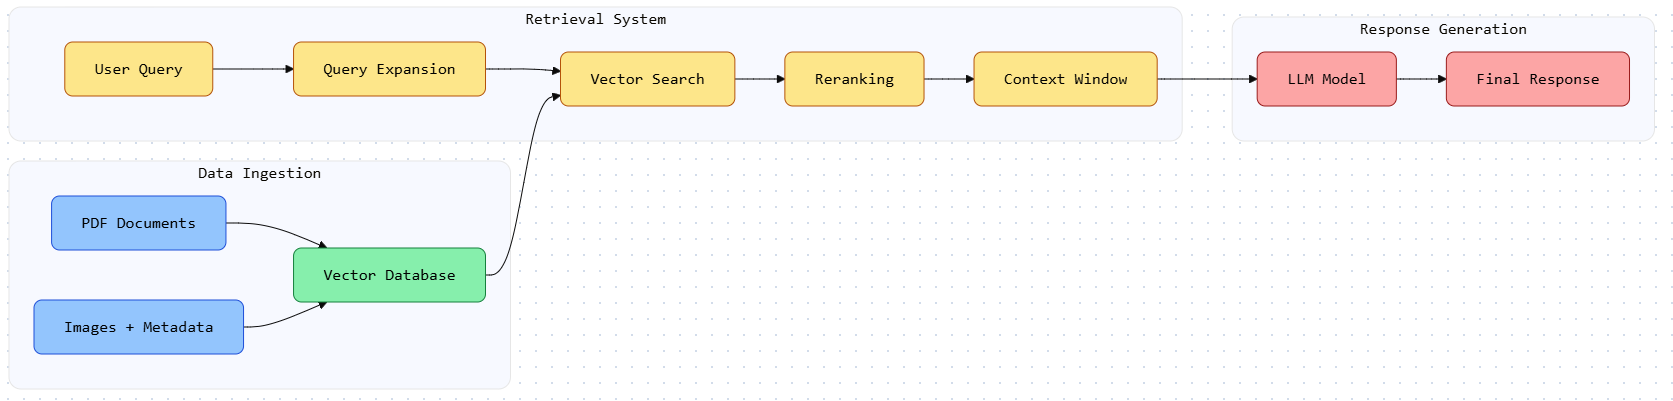

## **Setup**

In [1]:
# @title Run this cell => Restart the session => Start executing the below cells **(DO NOT EXECUTE THIS CELL AGAIN)**

!pip install -q langchain==0.3.21 \
                huggingface_hub==0.29.3 \
                openai==1.68.2 \
                chromadb==0.6.3 \
                langchain-community==0.3.20 \
                langchain_openai==0.3.10 \
                lark==1.2.2\
                rank_bm25==0.2.2\
                numpy==2.2.4 \
                scipy==1.15.2 \
                scikit-learn==1.6.1 \
                transformers==4.50.0 \
                pypdf==5.4.0 \
                markdown-pdf==1.7 \
                sentence_transformers==4.0.0 \
                torch==2.6.0+cu124


%pip install --upgrade chromadb
%pip install pillow
%pip install open-clip-torch
%pip install matplotlib

ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10; 1.7.2 Requires-Python >=3.7,<3.11; 1.7.3 Requires-Python >=3.7,<3.11; 1.8.0 Requires-Python >=3.8,<3.11; 1.8.0rc1 Requires-Python >=3.8,<3.11; 1.8.0rc2 Requires-Python >=3.8,<3.11; 1.8.0rc3 Requires-Python >=3.8,<3.11; 1.8.0rc4 Requires-Python >=3.8,<3.11; 1.8.1 Requires-Python >=3.8,<3.11
ERROR: Could not find a version that satisfies the requirement torch==2.6.0+cu124 (from versions: 2.0.0, 2.0.1, 2.1.0, 2.1.1, 2.1.2, 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0)
ERROR: No matching distribution found for torch==2.6.0+cu124


  Obtaining dependency information for chromadb from https://files.pythonhosted.org/packages/96/8a/f7e810f3cbdc9186ba4e649dc32711b7ab2c23aba37cf61175f731d22293/chromadb-1.0.16-cp39-abi3-win_amd64.whl.metadata
   ---------------------------------------- 0.0/19.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.6 MB 320.0 kB/s eta 0:01:02
   ---------------------------------------- 0.0/19.6 MB 320.0 kB/s eta 0:01:02
   ---------------------------------------- 0.0/19.6 MB 388.9 kB/s eta 0:00:51
   ---------------------------------------- 0.1/19.6 MB 655.4 kB/s eta 0:00:30
    --------------------------------------- 0.3/19.6 MB 1.7 MB/s eta 0:00:12
   - -------------------------------------- 0.8/19.6 MB 3.9 MB/s eta 0:00:05
   -- ------------------------------------- 1.2/19.6 MB 5.0 MB/s eta 0:00:04
   -- ------------------------------------- 1.2/19.6 MB 5.0 MB/s eta 0:00:04
   ---- ----------------------------------- 2.2/19.6 MB 7.5 MB/s eta 0:00:03
   ----- -----------

In [1]:
# Unzipping the Research Papers
import zipfile
with zipfile.ZipFile("content/M12 - Adv RAG.zip", 'r') as zip_ref:
  zip_ref.extractall("content/")

In [2]:
# @title Loading the `config.json` file
import json
import os

# Load the JSON file and extract values
file_name = 'config.json'
with open(file_name, 'r') as file:
    config = json.load(file)
    os.environ['AZURE_OPENAI_API_KEY'] = config.get("API_KEY") # Loading the API Key
    os.environ["AZURE_OPENAI_ENDPOINT"] = config.get("OPENAI_API_BASE") # Loading the API Base Url
    os.environ['OPENAI_API_VERSION'] = "2024-12-01-preview"


In [12]:
# @title Defining the Embedding Model - Using `text-embedding-ada-002` Model
from langchain_openai import AzureOpenAIEmbeddings
embeddings = AzureOpenAIEmbeddings(model="text-embedding-ada-002", show_progress_bar=True, max_retries=10, chunk_size=500)

In [4]:
# @title Defining the LLM Model - Using `gpt-4o-mini` Model
from langchain_openai import AzureChatOpenAI
llm = AzureChatOpenAI(model="gpt-4o-mini", temperature=0)

## **Step 1 : Loading the PDF and storing it in the vectorDB**


In [6]:
from langchain.document_loaders import PyPDFLoader

# Reading the NOFO Document
pdf_file = "content/MLS14 - Adv RAG/Vitamin_and_minerals.pdf"
pdf_loader = PyPDFLoader(pdf_file);
text_data = pdf_loader.load()
print(len(text_data))

362


In [8]:
print(text_data[0])

page_content='Vitamin and mineral
requirements
in human nutrition
Second edition
P000i-00xx  3/12/05  8:54 PM  Page i' metadata={'producer': 'Acrobat Distiller 4.05 for Macintosh', 'creator': 'Adobe Acrobat Pro 10.0.0', 'creationdate': '2014-08-17T14:09:06+02:00', 'moddate': '2014-08-17T14:09:06+02:00', 'title': '', 'source': 'content/MLS14 - Adv RAG/Vitamin_and_minerals.pdf', 'total_pages': 362, 'page': 0, 'page_label': '1'}


In [13]:
# Chunking the data
from langchain.text_splitter import RecursiveCharacterTextSplitter # type: ignore


# Split the doc into smaller chunks i.e. chunk_size=500
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=150)

chunks = text_splitter.split_documents(text_data)
print(len(chunks))

2570


In [14]:
from langchain.vectorstores import Chroma

text_vectorstore = Chroma(
    collection_name="vitamin_and_minerals",
    embedding_function=embeddings)

text_vectorstore.add_documents(documents=chunks)

  0%|          | 0/6 [00:00<?, ?it/s]

['8a519381-882e-44e6-bfe9-3c42ffc56584',
 '7f04723a-d523-4935-b478-aa3384156184',
 '5e36b1d6-5a63-4bf3-b9ea-8eac0af67298',
 '68aa6550-4d9b-45d4-b332-9bd3e6b9a873',
 'b3822ea9-ad24-43f4-9d6d-28c55e675a30',
 'f88d1049-0fab-4918-8aa1-1a23bdf1da1d',
 'c465b044-2623-492d-aefd-44d6f76ba84c',
 'c78cd2e7-ff93-4352-a669-b85baa197943',
 '06537750-9052-4526-b943-ea69430fdc0b',
 '6fed6570-9ba9-48b3-aa53-247d718148b2',
 'c26ae22c-1ddc-4bb3-8f17-2e2626291b0e',
 '0cd287d2-9692-419f-81d8-b078ecde699a',
 'b1bceb06-3227-4f02-93b2-e669991ff22c',
 'c35b10fa-14a5-4993-af4a-c3dc31cbab37',
 '78685a8a-a259-47d1-b5b9-a73953c7f06b',
 'becbfa80-a8ac-4ec0-b1f7-6f5fad923502',
 '4d926893-4a86-4c3e-a783-9aa081e4c394',
 'ed904162-cfee-4a2f-8706-805a05fec3b6',
 '89cdf943-2416-4d64-a2f3-19db39bd9b7e',
 '77469efb-72a0-45d5-901d-e7ddc72c61f7',
 'c4463a3d-c429-4174-bd92-08e16e317337',
 'b2ec4945-40c6-4a24-a381-53b4fef116b9',
 '10f89e51-0064-430e-9d21-a3fafcaf49d4',
 'a01e1e33-a0f4-4d03-85c3-abe06fd7bcc7',
 '0a6bf7e6-3bdb-

In [15]:
vanilla_retriever = text_vectorstore.as_retriever(search_kwargs={"k": 10})

## **Step 2 : Loading the Images along with metadata and storing them in the vectorDB**

In [16]:
import chromadb
from chromadb.utils.embedding_functions import OpenCLIPEmbeddingFunction
from chromadb.utils.data_loaders import ImageLoader
from matplotlib import pyplot as plt
import os

In [17]:
# Create database file at folder "my_vectordb" or load into client if exists
chroma_client = chromadb.PersistentClient(path="my_vectordb")

# Instantiate image loader helper
image_loader = ImageLoader()

# Instantiate multimodal embedding function
image_embedding_function = OpenCLIPEmbeddingFunction()

# Create the collection, aka vector database. Or, if database already exist, then use it. Specify the model that we want to use to do the embedding
multimodal_db = chroma_client.get_or_create_collection(name="multimodal_db", embedding_function=image_embedding_function, data_loader=image_loader)

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

c:\Users\Pheon\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:144: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Pheon\.cache\huggingface\hub\models--laion--CLIP-ViT-B-32-laion2B-s34B-b79K. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [18]:
multimodal_db.count()

0

In [20]:
from PIL import Image
import numpy as np

image_paths = [f"content/MLS14 - Adv RAG/sources/{file}" for file in os.listdir("content/MLS14 - Adv RAG/sources")]
image_paths

['content/MLS14 - Adv RAG/sources/VitaminA-1.png',
 'content/MLS14 - Adv RAG/sources/VitaminA-2.png',
 'content/MLS14 - Adv RAG/sources/VitaminA-3.png',
 'content/MLS14 - Adv RAG/sources/VitaminA-4.png',
 'content/MLS14 - Adv RAG/sources/VitaminA-5.png',
 'content/MLS14 - Adv RAG/sources/VitaminC-1.png',
 'content/MLS14 - Adv RAG/sources/VitaminC-2.png',
 'content/MLS14 - Adv RAG/sources/VitaminC-3.png',
 'content/MLS14 - Adv RAG/sources/VitaminD-1.png',
 'content/MLS14 - Adv RAG/sources/VitaminD-2.png',
 'content/MLS14 - Adv RAG/sources/VitaminD-3.png']

In [22]:
# Defining Metadata
Metadata = []
for file in os.listdir("content/MLS14 - Adv RAG/sources"):
  Metadata.append({'Vitamin':file.split("-")[0][-1],
                   'info': f'The images shows the sources of Vitamin {file.split("-")[0][-1]}'})

Metadata

[{'Vitamin': 'A', 'info': 'The images shows the sources of Vitamin A'},
 {'Vitamin': 'A', 'info': 'The images shows the sources of Vitamin A'},
 {'Vitamin': 'A', 'info': 'The images shows the sources of Vitamin A'},
 {'Vitamin': 'A', 'info': 'The images shows the sources of Vitamin A'},
 {'Vitamin': 'A', 'info': 'The images shows the sources of Vitamin A'},
 {'Vitamin': 'C', 'info': 'The images shows the sources of Vitamin C'},
 {'Vitamin': 'C', 'info': 'The images shows the sources of Vitamin C'},
 {'Vitamin': 'C', 'info': 'The images shows the sources of Vitamin C'},
 {'Vitamin': 'D', 'info': 'The images shows the sources of Vitamin D'},
 {'Vitamin': 'D', 'info': 'The images shows the sources of Vitamin D'},
 {'Vitamin': 'D', 'info': 'The images shows the sources of Vitamin D'}]

In [24]:
# Use .add() to add a new record or .update() to update existing record
multimodal_db.add(
    ids=[str(x) for x in range(len(os.listdir("content/MLS14 - Adv RAG/sources")))],
    uris = image_paths,
    metadatas=Metadata
)

In [25]:
multimodal_db.count()

11

In [26]:
# Simple function to print the results of a query.
# The 'results' is a dict {ids, distances, data, ...}
# Each item in the dict is a 2d list.
def print_query_results(query_list: list, query_results: dict)->None:
    result_count = len(query_results['ids'][0])

    for i in range(len(query_list)):
        for j in range(result_count):
            id       = query_results["ids"][i][j]
            distance = query_results['distances'][i][j]
            data     = query_results['data'][i][j]
            document = query_results['documents'][i][j]
            metadata = query_results['metadatas'][i][j]
            uri      = query_results['uris'][i][j]

            print(f'id: {id}, distance: {distance}, metadata: {metadata}, document: {document}')

            # Display image, the physical file must exist at URI.
            # (ImageLoader loads the image from file)
            print(f'data: {uri}')
            plt.imshow(data)
            plt.axis("off")
            plt.show()

In [27]:
def get_image(query_texts):
# Query vector db
    query_results = multimodal_db.query(
        query_texts = query_texts,
        n_results=2,
        include=['documents', 'distances', 'metadatas', 'data', 'uris'],
    )

    print_query_results(query_texts, query_results)

id: 5, distance: 1.4199875593185425, metadata: {'info': 'The images shows the sources of Vitamin C', 'Vitamin': 'C'}, document: None
data: content/MLS14 - Adv RAG/sources/VitaminC-1.png


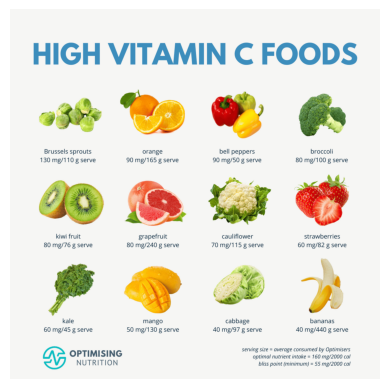

id: 6, distance: 1.4271095991134644, metadata: {'Vitamin': 'C', 'info': 'The images shows the sources of Vitamin C'}, document: None
data: content/MLS14 - Adv RAG/sources/VitaminC-2.png


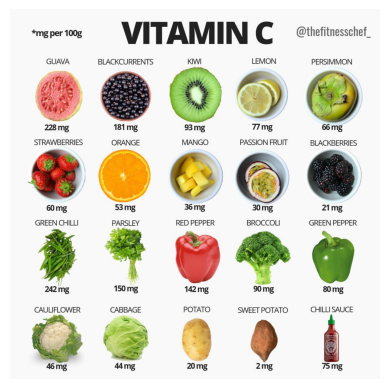

In [28]:
get_image(['Citrus fruits have which common vitamins'])

## **Reranking**

In [29]:
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
crossencoder = HuggingFaceCrossEncoder(model_name="cross-encoder/ms-marco-MiniLM-L-6-v2")

c:\Users\Pheon\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

c:\Users\Pheon\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:144: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Pheon\.cache\huggingface\hub\models--cross-encoder--ms-marco-MiniLM-L-6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HT

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

In [30]:
from langchain.retrievers.document_compressors import CrossEncoderReranker
reranker = CrossEncoderReranker(model=crossencoder, top_n=5)

In [31]:
from langchain.retrievers import ContextualCompressionRetriever
reranker_retriever = ContextualCompressionRetriever(
    base_compressor=reranker, base_retriever=vanilla_retriever
)

## **User Query Expansion**

In [32]:
# Query Expansion for User_query

def query_expansion(user_query):
    query_enhancement = f"""
    You are an expert in information retrieval systems, particularly skilled in enhancing queries for document search efficiency.
    Perform query expansion on the received question by considering alternative phrasings or synonyms commonly used in document retrieval contexts.
    If there are multiple ways to phrase the user's question or common synonyms for key terms, provide several reworded versions.

    If there are acronyms or words you are not familiar with, do not try to rephrase them.

    Return at least 3 versions of the question as a list.
    Generate only a list of questions. Do not mention anything before or after the list.

    Question:
    {user_query}
    """


    new_question = llm.invoke(query_enhancement)
    return (new_question.content)

<a id='Enhanced_Query'></a>
## **Step 3 : Retriever which can fetch the data from (PDF + Images) and return this to the user**

In [33]:
user_query = "What are the benefits of vitamin C & vitamin A"

In [34]:
# Query Expansion
multipule_queries = query_expansion(user_query)
print(multipule_queries)

1. What are the advantages of vitamin C and vitamin A?
2. What are the health benefits associated with vitamin C and vitamin A?
3. How does vitamin C and vitamin A contribute to health?


In [35]:
# Calling the vanilla retriever
vanilla_responses = vanilla_retriever.get_relevant_documents(multipule_queries)

# We can see the results are not sorted
context_query_pairs_for_scoring = [[multipule_queries, doc_text.page_content] for doc_text in vanilla_responses]
crossencoder.score(context_query_pairs_for_scoring)

C:\Users\Pheon\AppData\Local\Temp\ipykernel_14716\734080928.py:2: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  vanilla_responses = vanilla_retriever.get_relevant_documents(multipule_queries)


  0%|          | 0/1 [00:00<?, ?it/s]

array([-3.152581 , -2.1805754, -1.6520157, -2.5544286, -2.6761775,
       -3.464579 , -3.1602635, -1.6574608, -2.9022727, -3.0690293],
      dtype=float32)

**In the above cell, we can observe that we fetched 10 chunks and they are not sorted. Now, we will be following the re-ranking approach to fetch the 5 most relevant chunks from these 10.**

In [36]:
# Calling the reranking retriever
reranked_responses = reranker_retriever.get_relevant_documents(multipule_queries)

  0%|          | 0/1 [00:00<?, ?it/s]

In [37]:
# We can see the results are sorted
context_query_pairs_for_scoring = [[multipule_queries, doc_text.page_content] for doc_text in reranked_responses]
crossencoder.score(context_query_pairs_for_scoring)

array([-1.6520151, -1.6574599, -2.180575 , -2.5544286, -2.676177 ],
      dtype=float32)

In [47]:
for document in reranked_responses[:3]:
    print(document)
    print('=' * 50)

page_content='1.4 Conclusions 12
References 14
2. Vitamin A 17
2.1 Role of vitamin A in human metabolic processes 17
2.1.1 Overview of vitamin A metabolism 17
2.1.2 Biochemical mechanisms for vitamin A functions 19
2.2 Populations at risk for, and consequences of, vitamin A
deﬁciency 20
2.2.1 Deﬁnition of vitamin A deﬁciency 20
2.2.2 Geographic distribution and magnitude 20
2.2.3 Age and sex 21
iii
VITPR  3/12/05  16:50  Page iii' metadata={'moddate': '2014-08-17T14:09:06+02:00', 'source': 'content/MLS14 - Adv RAG/Vitamin_and_minerals.pdf', 'page_label': '3', 'title': '', 'creationdate': '2014-08-17T14:09:06+02:00', 'total_pages': 362, 'producer': 'Acrobat Distiller 4.05 for Macintosh', 'page': 2, 'creator': 'Adobe Acrobat Pro 10.0.0'}
page_content='opment are speciﬁcally associated with vitamin C status. This of course does
not preclude the possibility that other components in vitamin C-rich fruits
and vegetables provide health beneﬁts, but it is not yet possible to isolate such
effec

In [38]:
prompt = f"""
You are an expert AI assistant for question-answering tasks.
Use the following pieces of retrieved context to answer the question.

### Context:
{reranked_responses}

### Question:
{multipule_queries}
"""

In [39]:
llm_response = llm.invoke(prompt)

Answer: 
 ### Advantages and Health Benefits of Vitamin C and Vitamin A

1. **Advantages of Vitamin C:**
   - Vitamin C, also known as ascorbic acid, is essential for the growth and repair of tissues in the body. It plays a crucial role in the synthesis of collagen, which is vital for skin, cartilage, tendons, ligaments, and blood vessels.
   - It acts as a powerful antioxidant, helping to protect cells from damage caused by free radicals.
   - Vitamin C is important for the immune system, enhancing the body's ability to fight infections.
   - It aids in the absorption of iron from plant-based foods, which can help prevent anemia.

2. **Advantages of Vitamin A:**
   - Vitamin A is crucial for maintaining healthy vision, particularly in low-light conditions. It is a component of rhodopsin, a protein in the eyes that allows for vision in dim light.
   - It supports immune function, helping the body to fend off infections.
   - Vitamin A is important for skin health and cellular communica

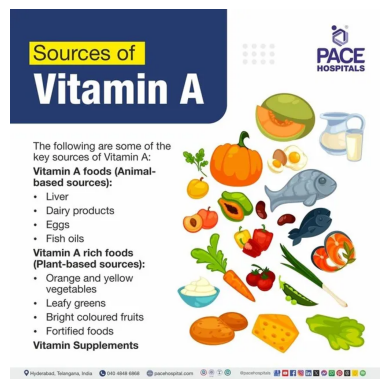

id: 5, distance: 1.4164927005767822, metadata: {'info': 'The images shows the sources of Vitamin C', 'Vitamin': 'C'}, document: None
data: content/MLS14 - Adv RAG/sources/VitaminC-1.png


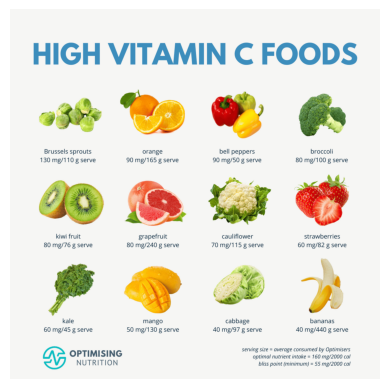

In [40]:
print("Answer: \n", llm_response.content)
print("="*50)
print("Relevant Images: \n")
get_image([llm_response.content])

**Note :** To improve the accuracy of retrieving relevant images, it's important to increase the number of images in the database the more images available, the better the system can identify and return relevant results.

<a id='Original_Query'></a>
## Original Query

In [48]:
# Calling the vanilla retriever
vanilla_responses = vanilla_retriever.get_relevant_documents(user_query)

# We can see the results are not sorted
context_query_pairs_for_scoring = [[user_query, doc_text.page_content] for doc_text in vanilla_responses]
crossencoder.score(context_query_pairs_for_scoring)

  0%|          | 0/1 [00:00<?, ?it/s]

array([ 1.6653968 , -3.7779002 , -1.3242236 , -4.284401  , -0.15491329,
        0.31556737, -1.7459733 , -2.5960336 ,  1.0603416 , -4.3609123 ],
      dtype=float32)

In [49]:
# Calling the reranking retriever
reranked_responses = reranker_retriever.get_relevant_documents(user_query)

  0%|          | 0/1 [00:00<?, ?it/s]

In [50]:
# We can see the results are sorted
context_query_pairs_for_scoring = [[user_query, doc_text.page_content] for doc_text in reranked_responses]
crossencoder.score(context_query_pairs_for_scoring)

array([ 1.6653968 ,  1.0603416 ,  0.31556737, -0.15491329, -1.3242236 ],
      dtype=float32)

In [51]:
for document in reranked_responses[:3]:
    print(document)
    print('=' * 50)

page_content='meeting vitamin A needs by including animal foods in the diet. For example,
providing minor amounts of ﬁsh or chicken liver (20–25g) in the diet pro-
vides more than the recommended vitamin A nutrient density for virtually all
population groups.
17.2.2 Vitamin C
An increased vitamin C intake can be achieved by including citrus fruit or
other foods rich in ascorbic acid in the diet. For example, an orange or a small
amount of other vitamin C-rich fruit (60g of edible portion) provides the' metadata={'moddate': '2014-08-17T14:09:06+02:00', 'title': '', 'total_pages': 362, 'creator': 'Adobe Acrobat Pro 10.0.0', 'page_label': '345', 'source': 'content/MLS14 - Adv RAG/Vitamin_and_minerals.pdf', 'producer': 'Acrobat Distiller 4.05 for Macintosh', 'creationdate': '2014-08-17T14:09:06+02:00', 'page': 344}
page_content='2. Vitamin A
17
2.1 Role of vitamin A in human metabolic processes
Vitamin A (retinol) is an essential nutrient needed in small amounts by
humans for the normal fu

In [52]:
prompt = f"""
You are an expert AI assistant for question-answering tasks.
Use the following pieces of retrieved context to answer the question.

### Context:
{reranked_responses}

### Question:
{user_query}
"""

In [53]:
llm_response = llm.invoke(prompt)

Answer: 
 Vitamin A and vitamin C are essential nutrients that play significant roles in human health.

### Benefits of Vitamin A:
1. **Visual Function**: Vitamin A is crucial for the normal functioning of the visual system, helping to maintain good eyesight.
2. **Growth and Development**: It supports growth and development, particularly in children.
3. **Cellular Integrity**: Vitamin A helps maintain the integrity of epithelial cells, which are important for the health of skin and mucous membranes.
4. **Immune Function**: It plays a vital role in immune system function, helping the body to fight infections.
5. **Reproductive Health**: Vitamin A is important for reproduction and overall reproductive health.

### Benefits of Vitamin C:
1. **Antioxidant Properties**: Vitamin C acts as an antioxidant, helping to protect cells from damage caused by free radicals.
2. **Cancer Risk Reduction**: Epidemiological studies suggest that a diet high in vitamin C may be associated with a lower risk 

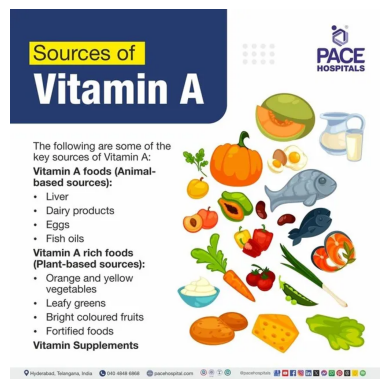

id: 3, distance: 1.3767900466918945, metadata: {'Vitamin': 'A', 'info': 'The images shows the sources of Vitamin A'}, document: None
data: content/MLS14 - Adv RAG/sources/VitaminA-4.png


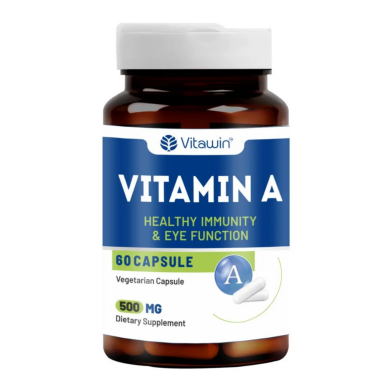

In [54]:
print("Answer: \n", llm_response.content)
print("="*50)
print("Relevant Images: \n")
get_image([llm_response.content])

## Hallucination

In [55]:
user_query = "What kind of dog has curly hair"

In [56]:
# Query Expansion
multipule_queries = query_expansion(user_query)
print(multipule_queries)

1. What breeds of dogs have curly fur?
2. Which types of dogs possess curly hair?
3. What dog breeds are known for their curly coats?


In [57]:
# Calling the vanilla retriever
vanilla_responses = vanilla_retriever.get_relevant_documents(multipule_queries)

# We can see the results are not sorted
context_query_pairs_for_scoring = [[multipule_queries, doc_text.page_content] for doc_text in vanilla_responses]
crossencoder.score(context_query_pairs_for_scoring)

  0%|          | 0/1 [00:00<?, ?it/s]

array([-6.0325446, -9.157389 , -7.4795656, -7.48175  , -8.9889345,
       -8.755428 , -6.2706184, -3.4766376, -8.992875 , -8.363932 ],
      dtype=float32)

**In the above cell, we can observe that we fetched 10 chunks and they are not sorted. Now, we will be following the re-ranking approach to fetch the 5 most relevant chunks from these 10.**

In [58]:
# Calling the reranking retriever
reranked_responses = reranker_retriever.get_relevant_documents(multipule_queries)

  0%|          | 0/1 [00:00<?, ?it/s]

In [59]:
# We can see the results are sorted
context_query_pairs_for_scoring = [[multipule_queries, doc_text.page_content] for doc_text in reranked_responses]
crossencoder.score(context_query_pairs_for_scoring)

array([-3.4766376, -6.0325446, -6.2706184, -7.4795656, -7.48175  ],
      dtype=float32)

In [60]:
for document in reranked_responses[:3]:
    print(document)
    print('=' * 50)

page_content='current scientiﬁc knowledge. Geneva, World Health Organization, 1998
(WHO/NUT/98.1).
P217-229  3/12/05  17:08  Page 228' metadata={'producer': 'Acrobat Distiller 4.05 for Macintosh', 'creationdate': '2014-08-17T14:09:06+02:00', 'page_label': '248', 'page': 247, 'total_pages': 362, 'source': 'content/MLS14 - Adv RAG/Vitamin_and_minerals.pdf', 'title': '', 'creator': 'Adobe Acrobat Pro 10.0.0', 'moddate': '2014-08-17T14:09:06+02:00'}
page_content='investigation among school children of Oregon. Journal of Paediatrics , 1952,
40:451–455.
97. Commission on Natural Resources. Mineral tolerance of domestic animals.
Washington, DC, National Academy of Sciences, 1980.
P194-216  3/12/05  17:07  Page 216' metadata={'creationdate': '2014-08-17T14:09:06+02:00', 'source': 'content/MLS14 - Adv RAG/Vitamin_and_minerals.pdf', 'page': 235, 'producer': 'Acrobat Distiller 4.05 for Macintosh', 'page_label': '236', 'creator': 'Adobe Acrobat Pro 10.0.0', 'moddate': '2014-08-17T14:09:06+02:00', 

In [61]:
prompt = f"""
You are an expert AI assistant for question-answering tasks.
Use the following pieces of retrieved context to answer the question.

### Context:
{reranked_responses}

### Question:
{multipule_queries}
"""

In [62]:
llm_response = llm.invoke(prompt)

Answer: 
 The context provided does not contain any information regarding dog breeds or their fur types. Therefore, I cannot answer the questions about which breeds of dogs have curly fur or possess curly hair. 

However, generally speaking, some dog breeds known for their curly coats include:

1. Poodle (Standard, Miniature, and Toy)
2. Portuguese Water Dog
3. Curly-Coated Retriever
4. Irish Water Spaniel
5. Lagotto Romagnolo

If you need more specific information or details about any of these breeds, feel free to ask!
Relevant Images: 

id: 8, distance: 1.6816825866699219, metadata: {'info': 'The images shows the sources of Vitamin D', 'Vitamin': 'D'}, document: None
data: content/MLS14 - Adv RAG/sources/VitaminD-1.png


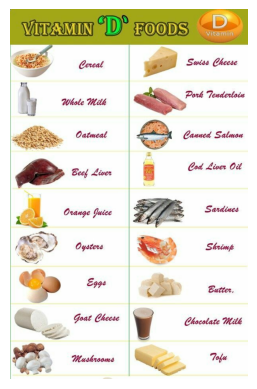

id: 4, distance: 1.6956074237823486, metadata: {'Vitamin': 'A', 'info': 'The images shows the sources of Vitamin A'}, document: None
data: content/MLS14 - Adv RAG/sources/VitaminA-5.png


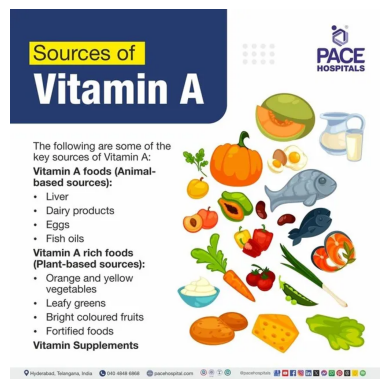

In [63]:
print("Answer: \n", llm_response.content)
print("="*50)
print("Relevant Images: \n")
get_image([llm_response.content])